### Convolutional neural network (CNN): Use MNIST Fashion Dataset and create a classifier to classify fashion clothing into categories.

In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
df=keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = df.load_data()

#class names for top 10 categories, given because dataset stores  labes as
#numbers, not words
classnames=['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal',
            'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

#normalize pixel values from [0,255] to [0, 1] for easier processing
#Each pixel stores brightness 0 = black, 255 = white, in between = gray shades
#easier to process
train_images = train_images / 255
test_images = test_images / 255
print("train images:", train_images.shape)
print("test images:", test_images.shape)
#output format:(number of images, img height, img width)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
train images: (60000, 28, 28)
test images: (10000, 28, 28)


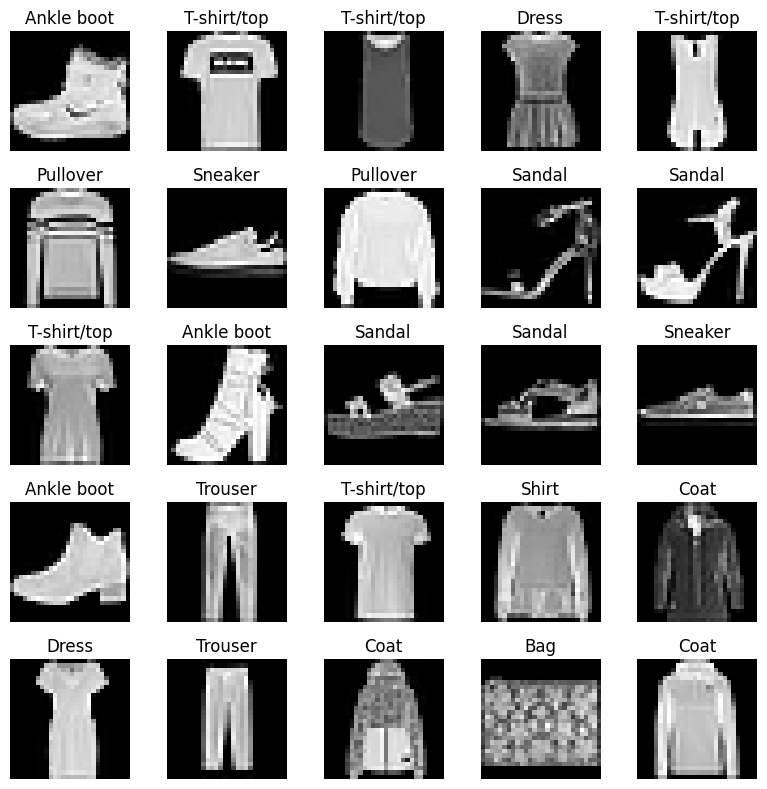

In [4]:
# Show first 9 training images with their labels
plt.figure(figsize=(8, 8))
for i in range(25):
  plt.subplot(5, 5, i + 1) #create 5x5 grid, i+1 tells position to place image.
  plt.imshow(train_images[i], cmap='gray')
  plt.title(classnames[train_labels[i]])
  plt.axis('off') #remove axes
plt.tight_layout() #Prevents images/titles from overlapping.
plt.show()

In [8]:
#build model

# original train_images shape=(60000, 28, 28) i.e (num of img, height, width)
#cnn needs in format (height, width, channels)
# channel is A separate layer of color information in an image
# rgb images have 3 channels(red green blue)
# grayscale images have only 1 channel so here channel is 1

train_images= train_images.reshape(-1,28,28,1)
#old=(num of img, height, width). now=(num of img, height, width, channel)
#num of img is -1 means TensorFlow automatically figure out number of images
#so tensorflow automatically assigns amt of imgs for train and test

test_images=test_images.reshape(-1,28,28,1)

#cnn layers:
#convolutional->maxpooling->flatten->fully connected dense->output
model=keras.Sequential([
    #1. convolutional
    keras.layers.Conv2D(64, (3,3), activation='relu', input_shape=(28,28,1)),
    #convolutional layer scans image and detects features like
    #edges, curves, shapes, patterns
    #Later deeper layers learn shoes, shirts, bags etc.

    # 64 filters/detectors are used. each learns different patterns like
    # 1 detects corners, 1 edges, 1 textures etc

    #(3,3) means kernel or filter size is 3x3.
    #kernel is filter size i.e Tiny square moving across image to
    #scan image piece by piece.

    #cnn checks if feature found and produces number. if number positive,
    #then feature is detected. if negative, not found.
    #we normalized pixel values, not prediction values so relu is used
    #to make negative ones to 0

    #input_shape=(28,28,1), cnn understands format of images 28x28, gray


    #2. maxpooling
    keras.layers.MaxPooling2D(2,2),
    #pooling reduces img size for less computation while keeping imp info
    #convolution makes feature maps i.e maps of features in img which are large
    #pooling reduces their size
    #maxpooling is a type of pooling to keep the strongest detected feature.
    #if feature map has values
    # 1 5
    # 2 9
    #cnn checks 2x2 area (as (2,2) given in params) and keeps 9
    #rest deleted, only max val remains

    #(2,2) means take a 2×2 region,  keep max value, move 2 steps.
    #so size reduced by half


    #3. flatten
    keras.layers.Flatten(),
    #till now output is 2d feature map. fully connected layer needs 1d vector
    #because it is designed that way so 2d flattened to 1d(2d array to 1d array)

    #4. fully connected dense layer 128 neurons
    keras.layers.Dense(128,activation='relu'),
    #takes all learned features and makes the final decision/classification
    #Every neuron connects to every input value.
    #output is probability of item belonging to each class (10 probabilities)

    #5. output dense layer with 10 neurons for 10 classes
    keras.layers.Dense(10, activation='softmax')
    #Softmax helps the model calculate probability for each class,compare them
    #and choose the most likely one.
])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10816)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,384,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,386,506 (5.29 MB)

 Trainable params: 1,386,506 (5.29 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', #used because we have 10 categories
    metrics=['accuracy']
)

In [10]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',   # watches validation loss
    patience=2,           # wait 2 epochs before stopping
)

historyvariable = model.fit(
train_images, train_labels,
epochs=10,
validation_split=0.1,
callbacks=[early_stop]
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.8645 - loss: 0.3809 - val_accuracy: 0.8838 - val_loss: 0.3165
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9061 - loss: 0.2551 - val_accuracy: 0.9102 - val_loss: 0.2529
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9224 - loss: 0.2072 - val_accuracy: 0.9165 - val_loss: 0.2363
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9353 - loss: 0.1735 - val_accuracy: 0.9093 - val_loss: 0.2600
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9475 - loss: 0.1425 - val_accuracy: 0.9172 - val_loss: 0.2550


In [11]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print('Test accuracy:', test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9158 - loss: 0.2610
Test accuracy: 0.9157999753952026


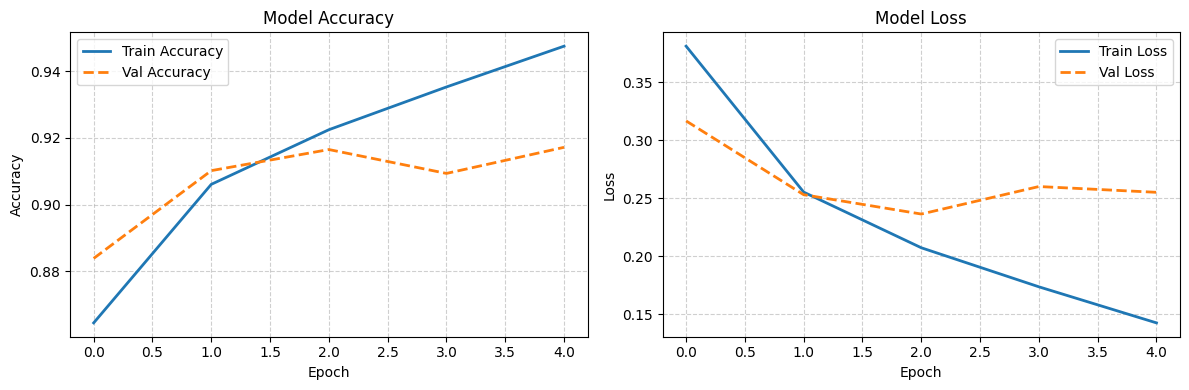

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# Accuracy plot
axes[0].plot(historyvariable.history['accuracy'],

linestyle='-', linewidth=2, label='Train Accuracy')

axes[0].plot(historyvariable.history['val_accuracy'],

linestyle='--', linewidth=2, label='Val Accuracy')

axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(frameon=True)
axes[0].grid(True, linestyle='--', alpha=0.6)
# Loss plot
axes[1].plot(historyvariable.history['loss'],

linestyle='-', linewidth=2, label='Train Loss')

axes[1].plot(historyvariable.history['val_loss'],

linestyle='--', linewidth=2, label='Val Loss')

axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(frameon=True)
axes[1].grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


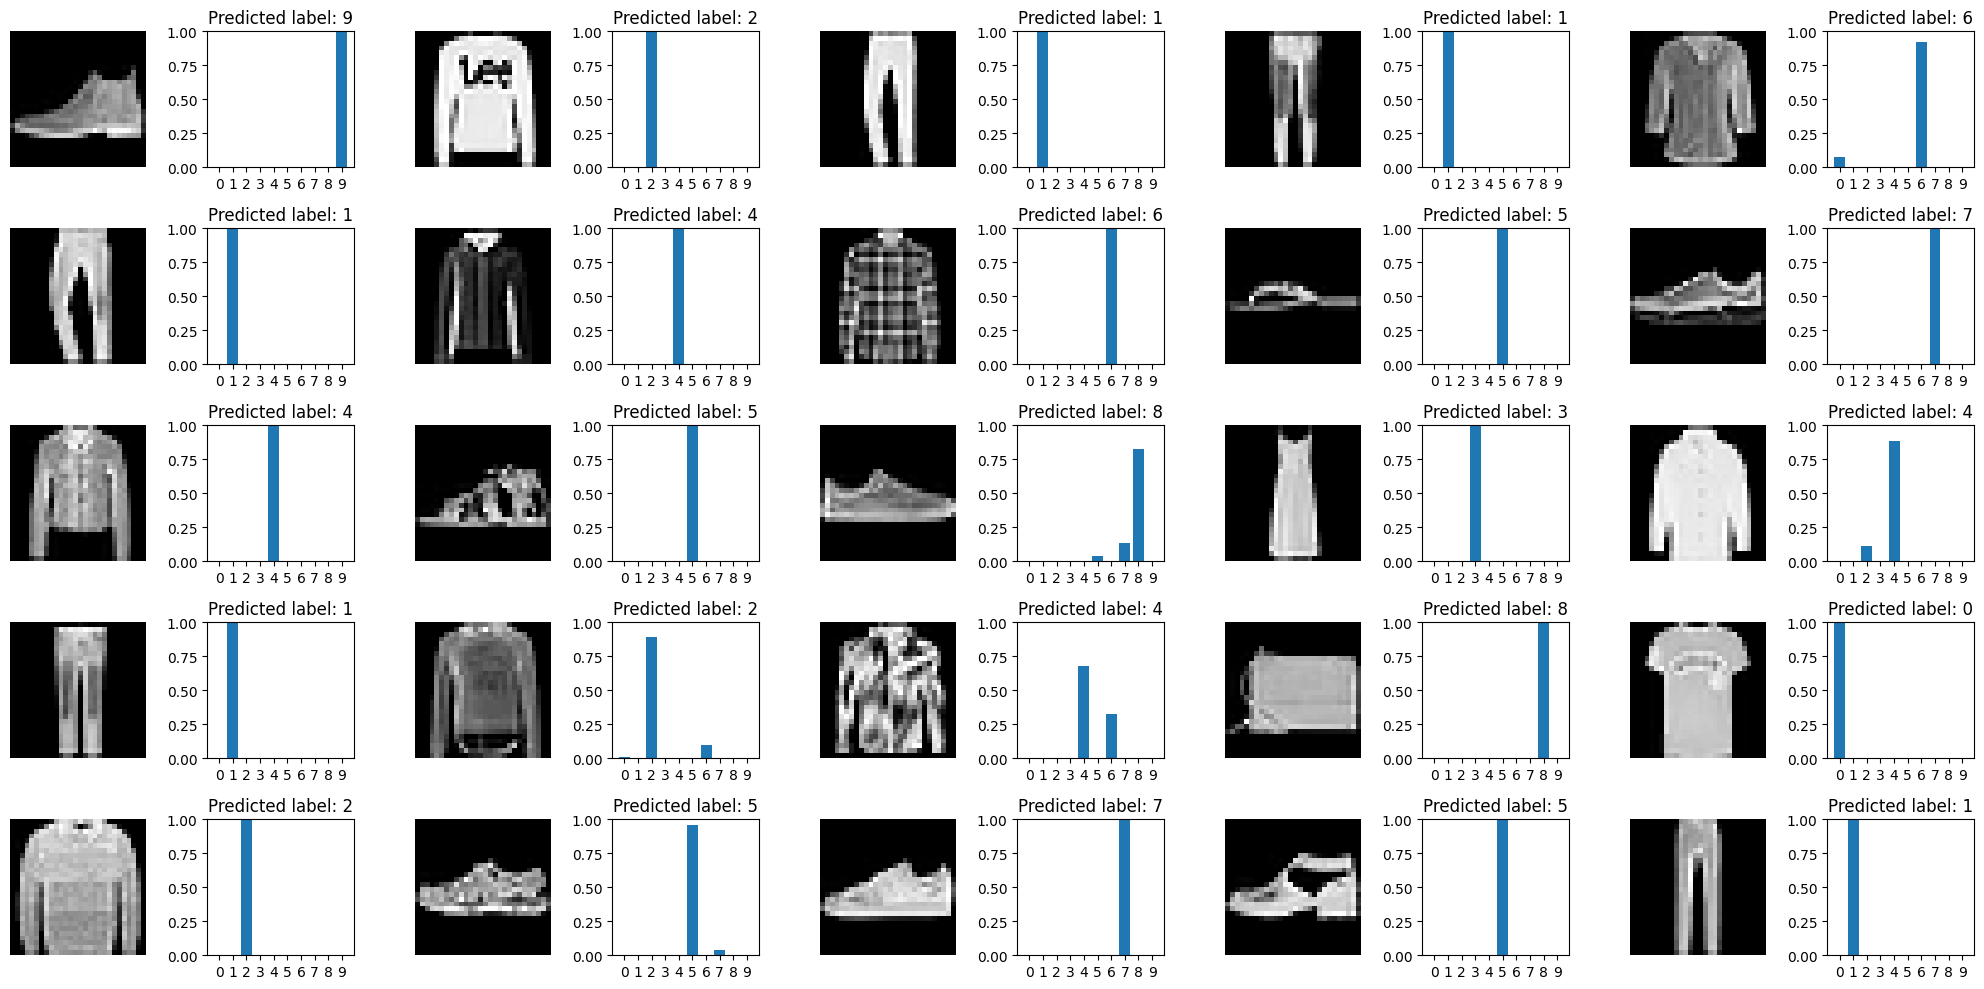

In [14]:
# Make predictions on test set
predictions = model.predict(test_images)
predicted_labels = np.argmax(predictions, axis=1) #argmax=find index of max val
# Show sample images and their predicted labels (matching lab manual output)
num_rows = 5
num_cols = 5
num_images = num_rows * num_cols
plt.figure(figsize=(2 * 2 * num_cols, 2 * num_rows))
for i in range(num_images):
  # Left subplot: image
  plt.subplot(num_rows, 2 * num_cols, 2 * i + 1)
  plt.imshow(test_images[i], cmap='gray')
  plt.axis('off')
  # Right subplot: prediction bar chart
  plt.subplot(num_rows, 2 * num_cols, 2 * i + 2)
  plt.bar(range(10), predictions[i])
  plt.xticks(range(10))
  plt.ylim([0, 1])
  plt.title(f"Predicted label: {predicted_labels[i]}")
plt.tight_layout()
plt.show()